# Regression

## Libraries

In [ ]:
from data_provider import load_data, normalize_data
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from visualizer import plot_regression_results as visualize

## 1. Data Loading and Splitting

In [ ]:
# Random
rs = 67 # SIX SEVEN

# Loading data
XX = "dane/dane1.txt"
X, y = load_data(XX)

# Splitting
X_train, X_test, y_train, y_test = normalize_data(train_test_split(X, y, test_size=0.2, random_state=rs))

## 2. Neural Network Design and Training

### 2.1 Underfitting

In [ ]:
regressor_batch_underfitting = MLPRegressor(hidden_layer_sizes=(100, 50), activation="tanh", max_iter=500, random_state=rs)
regressor_batch_underfitting.fit(X_train, y_train)

visualize(regressor_batch_underfitting, X_train, y_train, X_test, y_test, title="Regressor batch underfitting")

### 2.2 Optimal

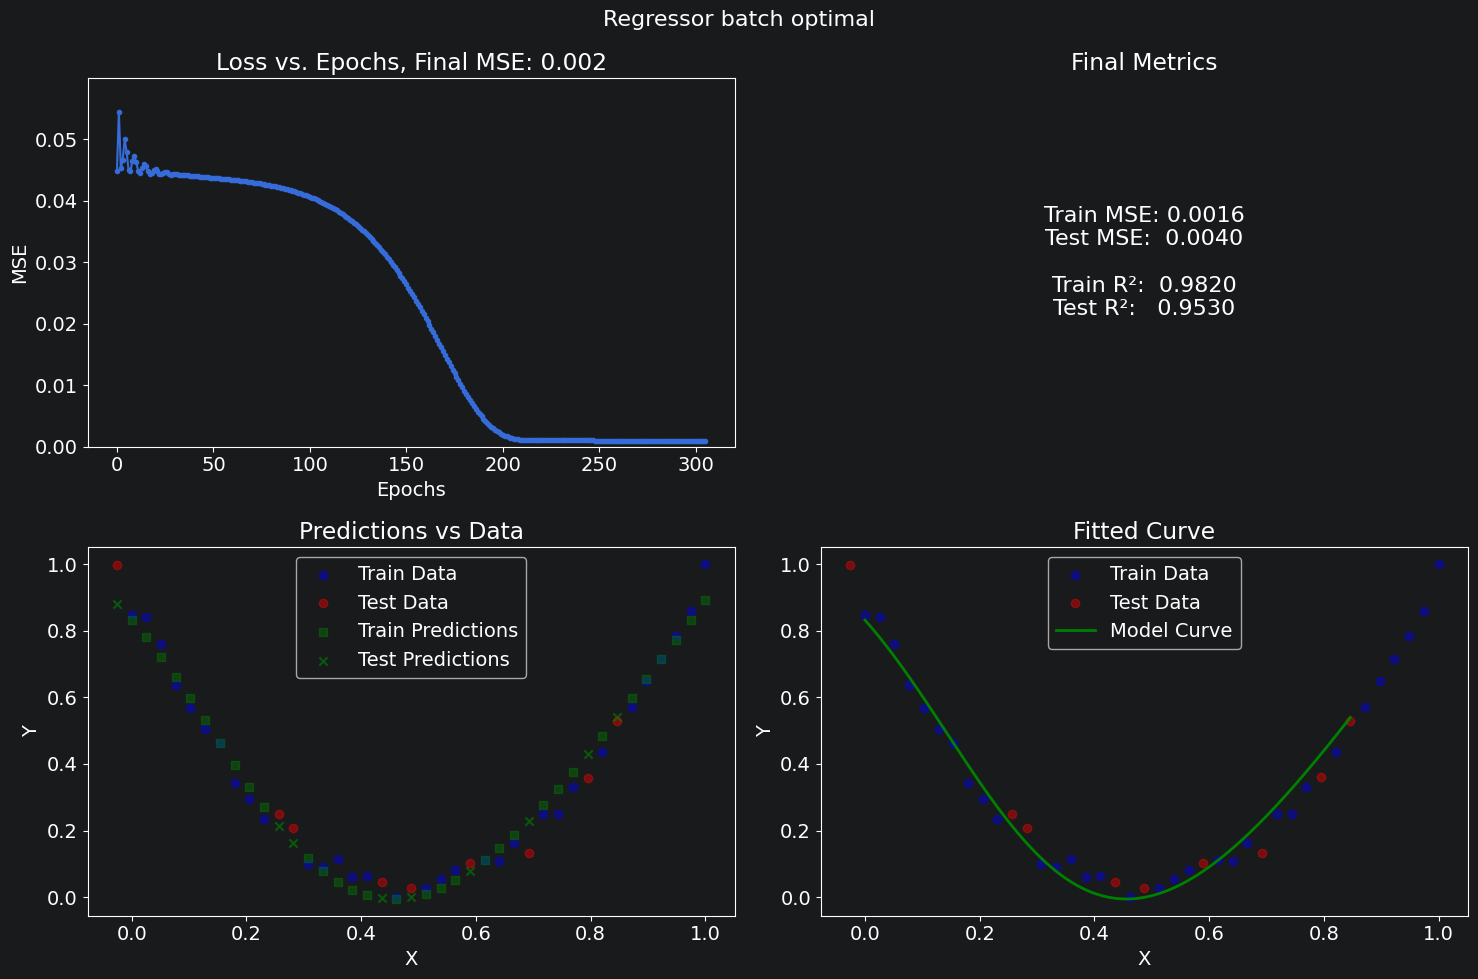

In [50]:
regressor_batch_optimal = MLPRegressor(hidden_layer_sizes=(100, 50), activation="tanh", max_iter=2100, n_iter_no_change=100, random_state=rs)
regressor_batch_optimal.fit(X_train, y_train)

visualize(regressor_batch_optimal, X_train, y_train, X_test, y_test, title="Regressor batch optimal")

### 2.3 Overfitting

In [ ]:
X_train_tiny = X_train[:5]
y_train_tiny = y_train[:5]

regressor_batch_overfit = MLPRegressor(hidden_layer_sizes=(500, 500), max_iter=2000, early_stopping=False, random_state=rs)
regressor_batch_overfit.fit(X_train_tiny, y_train_tiny)

visualize(regressor_batch_overfit, X_train_tiny, y_train_tiny, X_test, y_test, title="Regressor batch overfitting")

## 3. Network Evaluation - overfitting/underfitting

- **Underfitting:** early stopping triggered too soon (11–42 epochs), loss plateau never escaped, R² ≈ 0 on both train and test, flat predicted curve
- **Optimal fit:** (100, 50) tanh, ~300 epochs, Train R² = 0.9955 / Test R² = 0.9830, smooth curve following data shape, small train/test gap confirms good generalization
- **Overfitting:** forced by reducing training set to 5 samples, Train R² = 0.9788 but Test R² = 0.5905, curve memorized training points, failed on unseen data
- **Key insight:** dataset is low-noise smooth function, naturally resistant to overfitting under normal conditions, data scarcity is the main overfitting trigger here

## 4. Change Training Method

In [ ]:
regressor_online = MLPRegressor(hidden_layer_sizes=(100, 50), activation="tanh", solver='sgd', batch_size=1, max_iter=2000, n_iter_no_change=100, random_state=rs)
regressor_online.fit(X_train, y_train)

visualize(regressor_online, X_train, y_train, X_test, y_test, title="Regressor online optimal")

- **Loss curve:** batch is smooth with a clean drop around **epoch 150**, stochastic shows characteristic zigzag noise throughout the entire training, confirming stochastic weight updates per sample
- **Convergence speed:** batch converged in `~300 epochs`, online needed `~580 epochs` to reach similar loss level: **nearly 2x slower**
- **Final metrics:** batch achieved `Train R² = 0.9820 / Test R² = 0.9530`, online reached `Train R² = 0.9712 / Test R² = 0.9278`. Batch wins on both
- **MSE:** batch `Train/Test = 0.0016/0.0040`, online `Train/Test = 0.0026/0.0061`. Batch approximately **1.5x more precise**
- **Fitted curve:** both correctly captured the U-shaped parabolic pattern, visual difference is minimal despite metric gap
- **Conclusion:** batch training outperformed online on this dataset in terms of precision, stability and convergence speed

## 5. RELU Activation Function

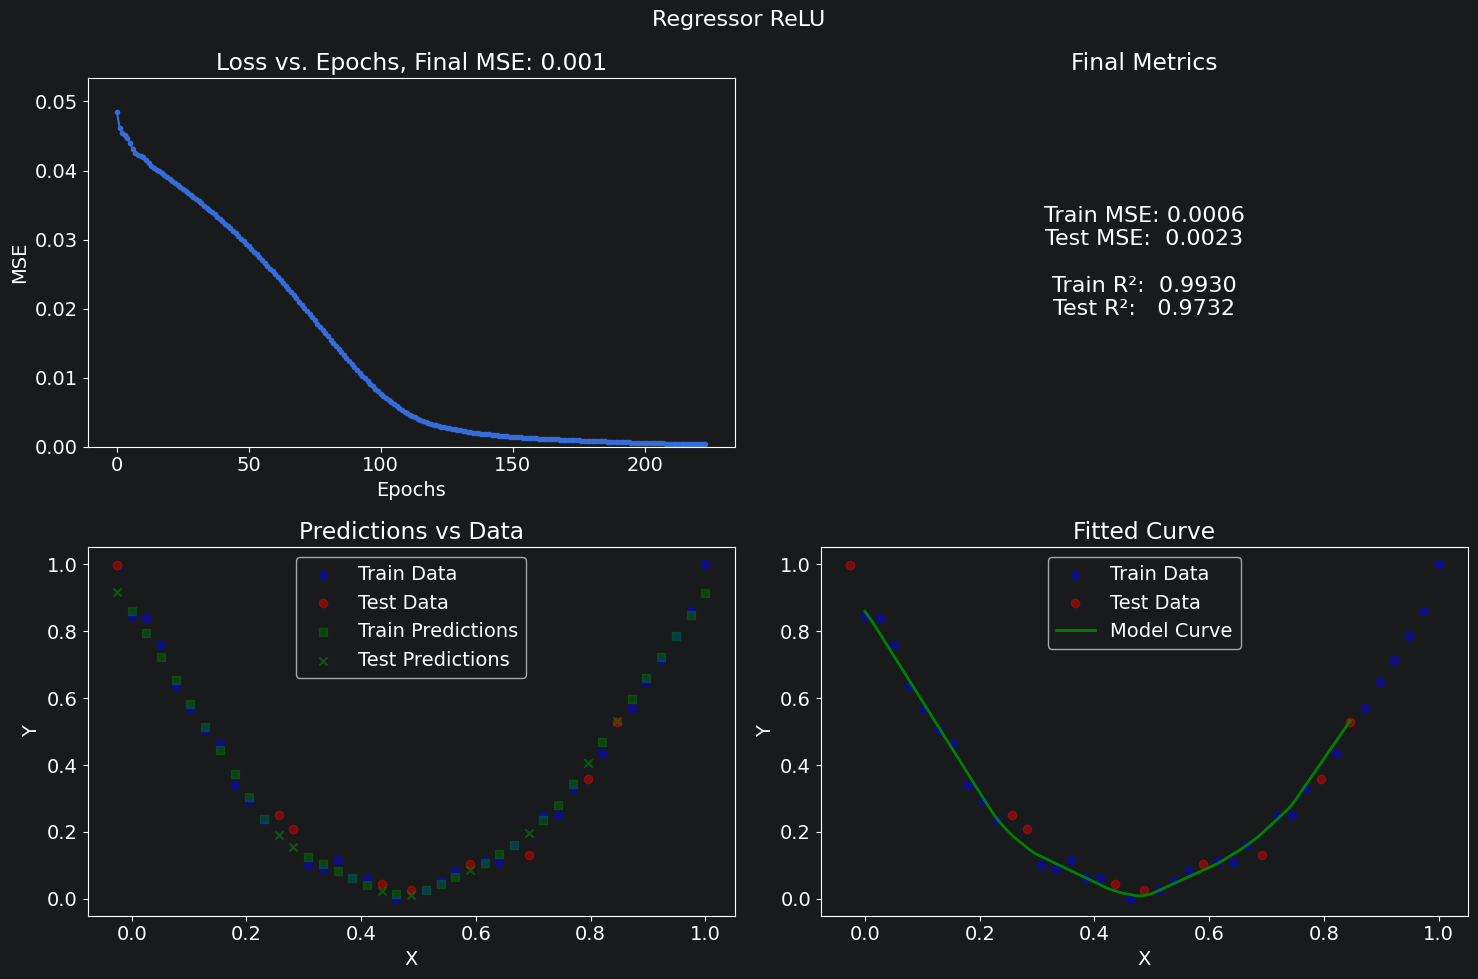

In [49]:
regressor_relu = MLPRegressor(hidden_layer_sizes=(100, 50), activation="relu", max_iter=2000, n_iter_no_change=100, random_state=rs)
regressor_relu.fit(X_train, y_train)

visualize(regressor_relu, X_train, y_train, X_test, y_test, title="Regressor ReLU")

- **Loss curve:** RELU shows a more steady curve, while tanh has a more pronounced drop around epoch 150
- **Convergence:** RELU converged in ~175 epochs, tanh in ~200 epochs, indicating RELU took fewer epochs to reach optimal performance
- **Final metrics:** ReLU `Train R² = 0.9930 / Test R² = 0.9732` vs tanh `Train R² = 0.9820 / Test R² = 0.9530`
- **Fitted curve:** ReLU produces piecewise linear approximation vs smooth tanh curve
- **Conclusion:** RELU showed better results than tanh on this dataset in all metrics.